In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
!pip install pydicom SimpleITK nibabel matplotlib pyvista -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 91.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.4/229.4 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.0/146.0 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 18.6 MB/s eta 0:00:00


In [4]:
import zipfile, os

zip_path = "/content/drive/MyDrive/OpenPlaque/Series7_BestDiast.zip"
out_dir = "/content/series7"

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(out_dir)

print("Extracted to", out_dir)

Extracted to /content/series7


In [7]:
import SimpleITK as sitk
import os

reader = sitk.ImageSeriesReader()

series_ids = reader.GetGDCMSeriesIDs("/content/series7/32210")

print("Series IDs found:", series_ids)

for sid in series_ids:
    files = reader.GetGDCMSeriesFileNames("/content/series7/32210", sid)
    print(f"{sid}: {len(files)} files")


Series IDs found: ('1.3.12.2.1107.5.1.4.76430.30000026012314584835400023821',)
1.3.12.2.1107.5.1.4.76430.30000026012314584835400023821: 524 files


In [8]:
files = reader.GetGDCMSeriesFileNames(
    "/content/series7/32210",
    "1.3.12.2.1107.5.1.4.76430.30000026012314584835400023821"
)

reader.SetFileNames(files)
image = reader.Execute()

print("Size:", image.GetSize())
print("Spacing:", image.GetSpacing())
print("Origin:", image.GetOrigin())

Size: (512, 512, 524)
Spacing: (0.3515625, 0.3515625, 0.3)
Origin: (-62.82421875, -255.82421875, 78.6)


Array shape: (524, 512, 512)
HU range: -1024 3071


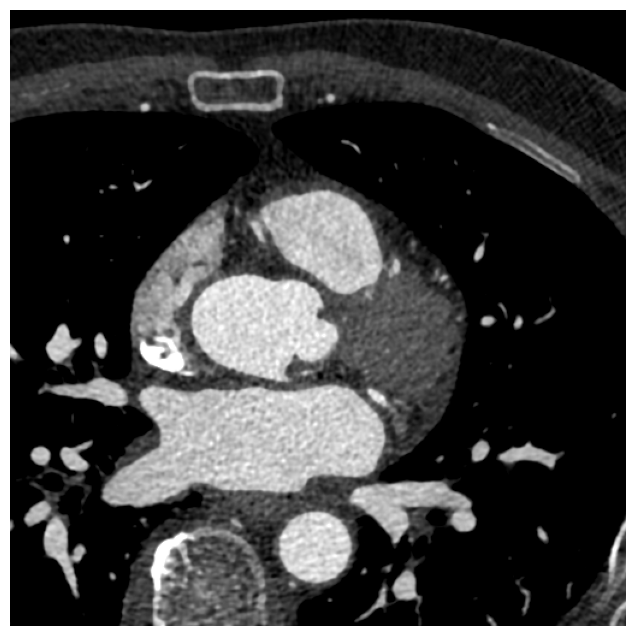

In [9]:
import matplotlib.pyplot as plt
import SimpleITK as sitk

volume = sitk.GetArrayFromImage(image)
print("Array shape:", volume.shape)
print("HU range:", volume.min(), volume.max())

mid = volume.shape[0] // 2
plt.figure(figsize=(8,8))
plt.imshow(volume[mid], cmap="gray", vmin=-200, vmax=800)
plt.axis("off")
plt.show()

In [12]:
print("Size:", image.GetSize())
print("Spacing:", image.GetSpacing())

Size: (512, 512, 524)
Spacing: (0.3515625, 0.3515625, 0.3)


In [13]:
import os
out_path = "/content/drive/MyDrive/OpenPlaque/series7_bestdiast.nii.gz"
sitk.WriteImage(image, out_path)
print("Saved:", out_path)

Saved: /content/drive/MyDrive/OpenPlaque/series7_bestdiast.nii.gz


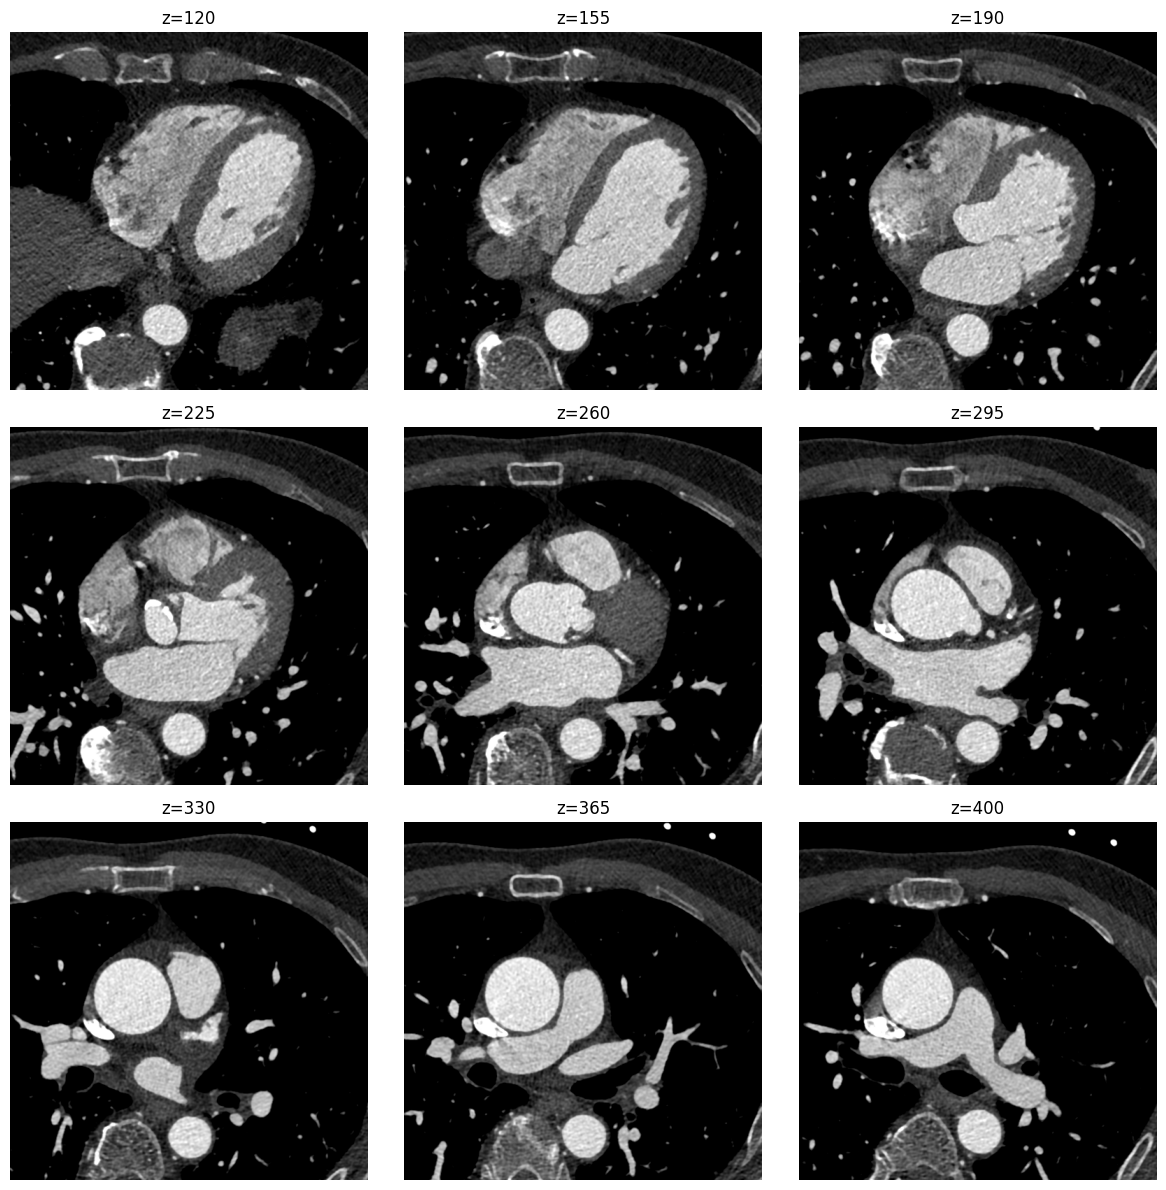

In [14]:
import numpy as np
import matplotlib.pyplot as plt

slices = np.linspace(120, 400, 9).astype(int)

plt.figure(figsize=(12,12))
for i, z in enumerate(slices):
    plt.subplot(3,3,i+1)
    plt.imshow(volume[z], cmap="gray", vmin=-200, vmax=800)
    plt.title(f"z={z}")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage as ndi

# Bright contrast/calcification threshold
mask = volume > 250

# Keep only central body region to reduce table/background artifacts
zmid = volume.shape[0] // 2
ymid = volume.shape[1] // 2
xmid = volume.shape[2] // 2

# Clean mask lightly
mask_clean = ndi.binary_opening(mask, iterations=1)
mask_clean = ndi.binary_closing(mask_clean, iterations=1)

print("Mask voxels:", mask_clean.sum())

Mask voxels: 18721889


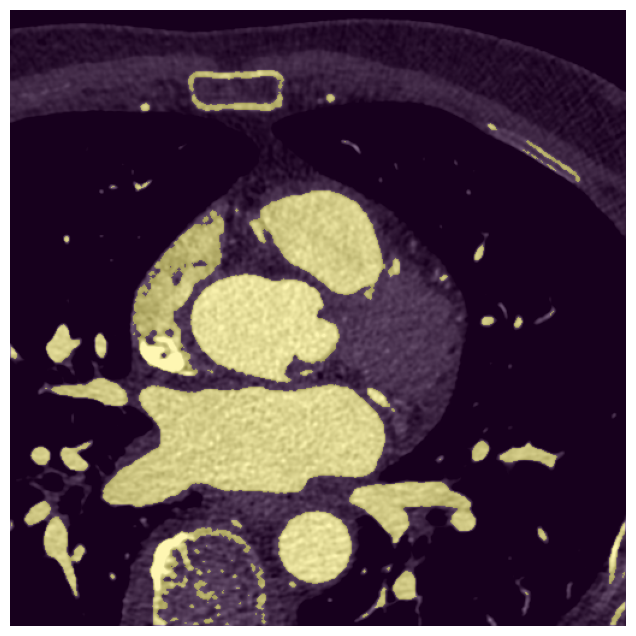

In [16]:
z = volume.shape[0] // 2

plt.figure(figsize=(8,8))
plt.imshow(volume[z], cmap="gray", vmin=-200, vmax=800)
plt.imshow(mask_clean[z], alpha=0.35)
plt.axis("off")
plt.show()